<a href="https://colab.research.google.com/github/m-julian/MACE-QTAIM/blob/main/mace_total_energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mace-torch
!pip install cuequivariance-torch

In [ ]:
import pandas as pd
import numpy as np
from ase import Atoms
from ase.io import write
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from ase.visualize.plot import plot_atoms
from ase.visualize import view

In [ ]:
# data from https://data.mendeley.com/datasets/2zws482yt6/1
df = pd.read_csv("C1_processed_data_alf_1_2_31.csv", header=0)
df.head()

,point_id,point_name,f1_C2,f2_H31,f3_H31,f4_O3,f5_O3,f6_O3,f7_N4,f8_N4,...,q33s,q40,q41c,q41s,q42c,q42s,q43c,q43s,q44c,q44s
0,1,TRP-SAMPLE-25002000,2.914871,2.014369,1.911335,4.592956,1.553795,0.447703,4.671739,1.638922,...,-0.667679,0.274072,-1.065518,-0.667325,0.739153,3.052716,-0.900173,0.114601,-0.776176,1.330675
1,2,TRP-SAMPLE-25002001,2.910086,2.045146,2.142029,4.567671,1.187585,-0.193896,4.575856,2.087751,...,0.318351,0.022767,-0.302192,-0.201386,-0.100157,3.685619,0.227912,-0.247024,-1.213594,1.074860
2,3,TRP-SAMPLE-25002002,2.829075,2.067377,1.741980,4.516788,1.382051,0.413541,4.515766,1.717005,...,-1.182645,-0.391551,-0.470185,-1.002651,0.913547,3.535262,0.084552,0.257382,-0.069181,1.700430
3,4,TRP-SAMPLE-25002003,2.924130,2.150541,1.929400,4.488500,2.045229,0.007235,4.658024,1.081270,...,-0.631272,-0.046439,-0.917789,-0.645637,0.537244,3.288060,-0.326109,0.599030,-0.772653,1.306860
4,5,TRP-SAMPLE-25002004,2.913369,1.987548,1.895630,4.579949,1.265505,-0.318164,4.630413,2.002896,...,-0.369775,-0.412864,-0.145226,0.323836,-0.367822,3.460193,0.118145,-0.355510,-0.654990,1.118998


In [ ]:
# taken from https://github.com/popelier-group/ichor/blob/d6a1a0263a8ff78a48231024ee0243201c084c71/ichor_core/ichor/core/calculators/alf_features_to_coordinates_calculator.py#L7

def spherical_to_cartesian(r, theta, phi) -> list[float]:
    r"""
    Spherical to cartesian transformation

    .. math::

        r \in [0, \inf)
        \theta in [0, \pi]
        \phi in [-\pi, \pi)

        x = r sin \theta cos\phi
        y = r sin \phi sin\theta
        z = r cos\theta
    """
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(theta)
    return [x, y, z]

def alf_features_to_coordinates(features: np.ndarray) -> np.ndarray:
    """Converts a given n_points x n_features matrix of features to cartesian coordinates of shape
    n_points x n_atoms x 3. Note cartesian coordinates are in Bohr as features
    are usually calculated in Bohr!

    :param features: a numpy array of shape n_points x n_features

    .. note::
        The distances in the features are in Bohr, so the resulting Cartesian
        coordinates will also be in Bohr. You will need to multiply by
        bohr2ang (in ichor.core.constants) to convert to Cartesian coordinates in Angstroms.
    """

    if features.ndim == 1:
        features = np.expand_dims(features, axis=0)

    all_points = []  # 3d array
    one_point = []  # 2d array

    for row in features:  # iterate over rows, which are individual points

        # origin and x-axis and xy-plane atoms
        one_point.append([0.0, 0.0, 0.0])
        one_point.append([row[0], 0.0, 0.0])
        # only have xy plane atom and others if molecule is not diatomic
        if len(row) > 1:
            one_point.append(
                spherical_to_cartesian(row[1], np.pi / 2, row[2])
            )  # theta is always pi/2 because it is in the xy plane

            # all other atoms
            for i in range(3, features.shape[-1], 3):
                r = row[i]
                theta = row[i + 1]
                phi = row[i + 2]
                one_point.append(spherical_to_cartesian(r, theta, phi))

        all_points.append(one_point)
        one_point = []

    return np.array(all_points)

In [ ]:
df_spherical = df[[i for i in df.columns if i.startswith("f")]].values
df_spherical.shape

(1932, 102)

In [ ]:
# covert from Bohr to Ang
X = alf_features_to_coordinates(df_spherical) * 0.529177
print(X.shape)
# convert from Eh to eV
Y = df["wfn_energy"].values * 27.2114
print(Y.shape)

feature_df_col_elements = [i.split("_")[1][0] for i in df.columns if i.startswith("f")]
SYMBOLS = ["C"] + [feature_df_col_elements[0], feature_df_col_elements[1]] + feature_df_col_elements[3::3]
print(SYMBOLS)
print(len(SYMBOLS))

(1932, 36, 3)
(1932,)
['C', 'C', 'H', 'O', 'N', 'C', 'C', 'O', 'C', 'C', 'C', 'C', 'N', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'N', 'C', 'H', 'H', 'H', 'H', 'H', 'H']
36


In [ ]:
frames = []
for coord, eng in zip(X, Y):
    atoms = Atoms(symbols=SYMBOLS, positions=coord)
    atoms.info["REF_energy"] = float(eng)
    atoms.info["config_type"] = "Default"
    frames.append(atoms)

write("train.xyz", frames[:-200], format="extxyz")
write("test.xyz", frames[-200:], format="extxyz")
print(f"wrote {len(frames)} structures")

wrote 1932 structures


In [ ]:
# check that atoms are correct
view(atoms, viewer='x3d')

In [ ]:
print(frames[1].info["REF_energy"])

-23360.383014281073


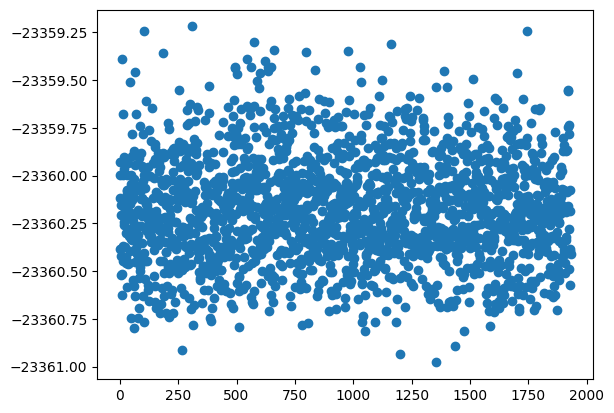

In [ ]:
plt.scatter(np.arange(len(Y)), Y)

In [ ]:
!mace_run_train \
  --name="energy_model" \
  --model="MACE" \
  --num_channels=64 \
  --train_file="train.xyz" \
  --test_file="test.xyz" \
  --valid_fraction=0.05 \
  --energy_key="REF_energy" \
  --loss="weighted" \
  --energy_weight=1.0 \
  --forces_weight=0.0 \
  --E0s="average" \
  --hidden_irreps='128x0e + 128x1o' \
  --r_max=5.0 \
  --batch_size=16 \
  --max_num_epochs=5 \
  --patience=5 \
  --ema --ema_decay=0.99 --amsgrad \
  --default_dtype="float64" \
  --device=cuda --seed=1

/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
2026-06-02 22:43:27.486 INFO: ===========VERIFYING SETTINGS===========
2026-06-02 22:43:27.487 INFO: MACE version: 0.3.16
2026-06-02 22:43:27.643 INFO: CUDA version: 12.8, CUDA device: 0
2026-06-02 22:43:27.681 INFO: ===========LOADING INPUT DATA===========
2026-06-02 22:43:27.681 INFO: Using heads: ['Default']
2026-06-02 22:43:27.681 INFO: Using the key specifications to parse data:
2026-06-02 22:43:27.681 INFO: Default: KeySpecification(info_keys={'energy': 'REF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability